# FOMC NLP Regime Model — Dual-Mandate Vol Forecasting

**Four coordinated changes to the NLP-vol forecasting stack.**

| Change | What | Why |
|--------|------|-----|
| **C1** | Expand corpus: press-conference transcripts + Jackson Hole speeches | Chair spoken word carries more signal than written statement alone |
| **C2** | Replace chair-identity with dual-mandate economic regime (FRED) | Powell alone spans four regimes — chair is a poor proxy |
| **C3** | Regime-conditional model, walk-forward OOS on Powell tenure | OOS validation only; regime must be economically primitive |
| **C4** | 6-panel figure suite with shared warm/cool regime palette | Annotation of JH 2022 'pain' episode throughout |

> **GOVERNING PRINCIPLE:** Regime conditioning adds parameters — on a smallish sample
> this overfits easily.  The regime variable MUST be economically primitive (defined
> independently of any vol outcome) and interactions MECHANISM-motivated, not
> fit-chased.  Validate that regime conditioning improves **OUT-OF-SAMPLE**, not
> just in-sample.  If it does not, say so.

---
## Cell 1 — Imports & Configuration

In [1]:
from __future__ import annotations
import os, re, json, hashlib, time, warnings
from pathlib import Path
from datetime import date, datetime, timedelta
from typing import Optional

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

from scipy import stats as sp_stats
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")
matplotlib.use("Agg")

try:
    from IPython import get_ipython as _gip
    _ip = _gip()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
        matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass

try:
    from IPython.display import display as _display
except ImportError:
    def _display(*a, **kw): pass  # type: ignore

# ── Paths ─────────────────────────────────────────────────────────────────────
CACHE_DIR  = Path("fomc_cache")
FIG_DIR    = Path("figures")
VRP_CACHE  = Path("vrp_cache")
CORPUS_OUT = Path("fomc_corpus_expanded.parquet")
REGIME_OUT = Path("fomc_dual_mandate_regime.parquet")
MODEL_OUT  = Path("fomc_nlp_regime_forecasts.parquet")
for d in (CACHE_DIR / "html", CACHE_DIR / "market", FIG_DIR, VRP_CACHE):
    d.mkdir(parents=True, exist_ok=True)

# ── API keys ──────────────────────────────────────────────────────────────────
FRED_API_KEY = os.environ.get("FRED_API_KEY", "6a9808ddeb9c3a8568dfb734f5c2303c")

# ── Feed base URLs ────────────────────────────────────────────────────────────
FED_BASE        = "https://www.federalreserve.gov"
PRESSCONF_URL_T = FED_BASE + "/monetarypolicy/fomcpresconf{date}.htm"
SPEECH_URL_T    = FED_BASE + "/newsevents/speech/{slug}.htm"
RATE_LIMIT_S    = 1.5

POWELL_START   = pd.Timestamp("2018-02-03")
PAIN_SPEECH_DT = pd.Timestamp("2022-08-26")
MIN_TRAIN      = 15
ALPHA_RANGE    = np.logspace(-2, 3, 30)

# ── Shared regime palette (warm=overheating, cool=slack/easing) ───────────────
REGIME_PALETTE = {
    "overheating":  "#d73027",
    "supply_shock": "#fc8d59",
    "at_target":    "#878787",
    "slack":        "#4575b4",
    "easing":       "#91bfdb",
}
REGIME_ORDER  = ["easing", "slack", "at_target", "supply_shock", "overheating"]
TEXT_FEATURES = ["uncertainty_density", "disagree_density", "guidance_specificity"]

_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 Chrome/124.0.0.0 Safari/537.36"
    ),
}

# ── Jackson Hole speeches (hardcoded public URLs) ─────────────────────────────
JACKSON_HOLE_SPEECHES = [
    dict(date="2018-08-24", chair="Powell", slug="powell20180824a"),
    dict(date="2019-08-23", chair="Powell", slug="powell20190823a"),
    dict(date="2021-08-27", chair="Powell", slug="powell20210827a"),
    dict(date="2022-08-26", chair="Powell", slug="powell20220826a"),   # 'pain'
    dict(date="2023-08-25", chair="Powell", slug="powell20230825a"),
    dict(date="2024-08-23", chair="Powell", slug="powell20240823a"),
    dict(date="2012-08-31", chair="Bernanke", slug="bernanke20120831a"),
    dict(date="2014-08-22", chair="Yellen",   slug="yellen20140822a"),
    dict(date="2016-08-26", chair="Yellen",   slug="yellen20160826a"),
]

print("Configuration loaded.")
print(f"  FIG_DIR  : {FIG_DIR.resolve()}")
print(f"  CACHE    : {CACHE_DIR.resolve()}")
print(f"  FRED key : {'env' if os.environ.get('FRED_API_KEY') else 'default (public)'}")

Configuration loaded.
  FIG_DIR  : /Users/zinuoshi/fomc-vol-study-repo/figures
  CACHE    : /Users/zinuoshi/fomc-vol-study-repo/fomc_cache
  FRED key : default (public)


---
## Cell 2 — C1: Press-Conference Q&A Stripper

The Fed publishes full verbatim transcripts at `fomcpresconf{YYYYMMDD}.htm`.
Each transcript interleaves:
- **Chair turns**: `CHAIR POWELL.  We have seen ...`
- **Reporter turns**: `JENNIFER SCHONBERGER.  [Question ...]`

We keep **only** chair spoken turns (signal) and drop all reporter text (noise).
After stripping, the text is converted to a **score density per 1,000 tokens**
so a 6,000-word Q&A and a 130-word statement produce comparable scale.

In [2]:
_CHAIR_NAMES = {"POWELL", "YELLEN", "BERNANKE", "GREENSPAN", "BURNS"}


def _fetch(url: str, delay: float = RATE_LIMIT_S) -> Optional[str]:
    """Disk-cached HTTP GET with rate limiting."""
    key  = hashlib.md5(url.encode()).hexdigest()[:16]
    path = CACHE_DIR / "html" / f"{key}.html"
    if path.exists():
        return path.read_text(encoding="utf-8", errors="replace")
    time.sleep(delay)
    try:
        r = requests.get(url, headers=_HEADERS, timeout=25)
        r.raise_for_status()
        path.write_text(r.text, encoding="utf-8")
        return r.text
    except Exception as e:
        print(f"  FETCH FAILED {url}: {e}")
        return None


def _strip_presser_to_chair(raw_text: str) -> tuple[str, int, int]:
    """
    Keep only chair spoken turns; drop reporter questions.
    Returns (chair_text, n_chair_turns, n_total_turns).
    """
    TURN_RE = re.compile(r"\n([A-Z][A-Z\s'\-]{2,40})[.\:]\s+")
    parts   = TURN_RE.split(raw_text)
    chair_turns, total = [], 0
    i = 1
    while i + 1 < len(parts):
        speaker  = parts[i].strip().upper()
        turn_txt = parts[i + 1].strip()
        i += 2
        total += 1
        if any(w in _CHAIR_NAMES for w in speaker.split()) and turn_txt:
            chair_turns.append(turn_txt)
    return "\n".join(chair_turns), len(chair_turns), total


def scrape_presser(meeting_date_str: str) -> Optional[dict]:
    """Fetch & parse one FOMC press-conference transcript."""
    url  = PRESSCONF_URL_T.format(date=meeting_date_str.replace("-", ""))
    html = _fetch(url)
    if html is None or "404" in html[:500]:
        return None
    soup    = BeautifulSoup(html, "html.parser")
    content = (soup.find("div", {"class": lambda c: c and "col-sm-8" in c})
               or soup.find("article")
               or soup.find("div", id="article")
               or soup.body)
    if content is None:
        return None
    raw_text = content.get_text(separator="\n", strip=True)
    if len(raw_text) < 500:
        return None
    chair_text, n_chair, n_total = _strip_presser_to_chair(raw_text)
    if len(chair_text) < 100:
        lines      = [l for l in raw_text.split("\n") if len(l.strip()) > 20]
        chair_text = "\n".join(lines)
        n_chair, n_total = 1, 1
    return dict(meeting_date=meeting_date_str, text=chair_text,
                n_tokens=len(chair_text.split()), n_chair_turns=n_chair,
                n_total_turns=n_total, doc_type="presser")


def scrape_speech(slug: str, speech_date: str, chair: str) -> Optional[dict]:
    """Fetch a Fed Board speech (monologue — no Q&A stripping needed)."""
    html = _fetch(SPEECH_URL_T.format(slug=slug))
    if html is None:
        return None
    soup    = BeautifulSoup(html, "html.parser")
    content = (soup.find("div", {"class": lambda c: c and "col-sm-8" in c})
               or soup.find("article") or soup.body)
    if content is None:
        return None
    for tag in content.find_all(["nav", "header", "footer", "script", "style"]):
        tag.decompose()
    lines = [l.strip() for l in content.get_text(separator="\n", strip=True).split("\n")
             if len(l.strip().split()) >= 5]
    text  = "\n".join(lines)
    if len(text.split()) < 100:
        return None
    return dict(meeting_date=speech_date, chair=chair, text=text,
                n_tokens=len(text.split()), doc_type="speech")

print("Presser / speech scrapers defined.")

Presser / speech scrapers defined.


---
## Cell 3 — C1: Build Expanded Corpus

Three document layers merged into one parquet:

| Layer | Source | n (approx) |
|-------|--------|------------|
| A | FOMC statements (`fomc_statements.parquet`) | ~130 |
| B | Press-conference transcripts (Fed website) | ~60 |
| C | Jackson Hole speeches (Fed website) | ~9 |

**Heterogeneity note:** Each document is tagged `doc_type ∈ {statement, presser, speech}`.
The model includes `is_presser` and `is_speech` dummies as controls.

In [3]:
_PRESSER_DATES = [
    "2011-04-27","2011-06-22","2011-09-21","2011-12-13",
    "2012-01-25","2012-04-25","2012-06-20","2012-09-13","2012-12-12",
    "2013-03-20","2013-06-19","2013-09-18","2013-12-18",
    "2014-01-29","2014-03-19","2014-06-18","2014-09-17","2014-12-17",
    "2015-03-18","2015-06-17","2015-09-17","2015-12-16",
    "2016-03-16","2016-06-15","2016-09-21","2016-12-14",
    "2017-03-15","2017-06-14","2017-09-20","2017-12-13",
    "2018-03-21","2018-06-13","2018-09-26","2018-12-19",
    "2019-01-30","2019-03-20","2019-05-01","2019-06-19",
    "2019-07-31","2019-09-18","2019-10-30","2019-12-11",
    "2020-01-29","2020-03-15","2020-04-29","2020-06-10",
    "2020-07-29","2020-09-16","2020-11-05","2020-12-16",
    "2021-01-27","2021-03-17","2021-04-28","2021-06-16",
    "2021-07-28","2021-09-22","2021-11-03","2021-12-15",
    "2022-01-26","2022-03-16","2022-05-04","2022-06-15",
    "2022-07-27","2022-09-21","2022-11-02","2022-12-14",
    "2023-02-01","2023-03-22","2023-05-03","2023-06-14",
    "2023-07-26","2023-09-20","2023-11-01","2023-12-13",
    "2024-01-31","2024-03-20","2024-05-01","2024-06-12",
    "2024-07-31","2024-09-18","2024-11-07","2024-12-18",
    "2025-01-29","2025-03-19","2025-05-07","2025-06-18",
    "2026-01-28","2026-03-18","2026-04-29","2026-06-17",
]


def build_expanded_corpus(force_refresh: bool = False) -> pd.DataFrame:
    if CORPUS_OUT.exists() and not force_refresh:
        df = pd.read_parquet(CORPUS_OUT)
        df["meeting_date"] = pd.to_datetime(df["meeting_date"])
        print(f"Corpus loaded from cache: {len(df)} documents")
        print("  " + str(df["doc_type"].value_counts().to_dict()))
        return df

    rows: list[dict] = []

    # Layer A — statements
    stmt_path = Path("fomc_statements.parquet")
    if stmt_path.exists():
        stmts = pd.read_parquet(stmt_path)
        stmts["doc_type"]   = "statement"
        stmts["n_tokens"]   = stmts["text"].str.split().str.len().fillna(0).astype(int)
        stmts["is_jh_pain"] = False
        rows.extend(stmts.to_dict("records"))
        print(f"  [A] Statements: {len(stmts)}")
    else:
        print("  [A] WARNING: fomc_statements.parquet not found")

    # Layer B — press conferences
    n_ok = n_fail = 0
    for ds in _PRESSER_DATES:
        r = scrape_presser(ds)
        if r:
            r["is_jh_pain"] = False
            rows.append(r); n_ok += 1
        else:
            n_fail += 1
    print(f"  [B] Press conferences: {n_ok} fetched, {n_fail} not found")

    # Layer C — Jackson Hole speeches
    n_ok = n_fail = 0
    for spec in JACKSON_HOLE_SPEECHES:
        r = scrape_speech(spec["slug"], spec["date"], spec["chair"])
        if r:
            r["is_jh_pain"] = (pd.Timestamp(spec["date"]) == PAIN_SPEECH_DT)
            rows.append(r); n_ok += 1
        else:
            n_fail += 1
    print(f"  [C] Jackson Hole speeches: {n_ok} fetched, {n_fail} not found")

    df = pd.DataFrame(rows)
    df["meeting_date"] = pd.to_datetime(df["meeting_date"])
    df = df.sort_values(["meeting_date","doc_type"]).reset_index(drop=True)

    print(f"\n  Token count audit:")
    for dt, grp in df.groupby("doc_type"):
        t = grp["n_tokens"].describe()
        print(f"    {dt:10s}  n={len(grp):3d}  "
              f"mean={t['mean']:,.0f}  min={t['min']:,.0f}  max={t['max']:,.0f}")
    print(f"\n  Total corpus: {len(df)} documents")

    df.to_parquet(CORPUS_OUT, index=False)
    print(f"  Saved → {CORPUS_OUT}")
    return df


corpus_df = build_expanded_corpus()
corpus_df[["meeting_date","doc_type","n_tokens","is_jh_pain"]].tail(20)

Corpus loaded from cache: 219 documents
  {'statement': 133, 'presser': 86}


,meeting_date,doc_type,n_tokens,is_jh_pain
199,2024-12-18,statement,361,False
200,2025-01-29,presser,8935,False
201,2025-01-29,statement,322,False
202,2025-03-19,presser,9172,False
203,2025-03-19,statement,381,False
204,2025-05-07,presser,8564,False
205,2025-05-07,statement,338,False
206,2025-06-18,presser,9378,False
207,2025-06-18,statement,311,False
208,2025-07-30,statement,341,False


---
## Cell 4 — C2: Dual-Mandate Economic Regime Labels

**Rationale (printed):** Chair identity is a poor regime proxy.
Powell alone spanned:
- 2018–2019: gradual normalisation (`AT_TARGET`)
- 2020 Q2: COVID shock (`SLACK` — sharp surge in unemployment)
- 2021 Q4 – 2023: inflation surge (`OVERHEATING` — fastest hiking since 1980s)
- 2024–2025: normalisation back to target (`AT_TARGET`)

One chair, four distinct regimes.  If `chair=Powell` is the regime label,
all four epochs get the same model weight — that is **economically wrong**.

**FRED inputs (primitiveness guarantee):** UNRATE, PCEPILFE, NROU, DGS3MO
are defined by BLS/BEA/FOMC — never from vol outcomes.

**Discrete thresholds (set from Taylor-rule mechanism):**
| Label | Condition |
|-------|-----------|
| `overheating` | inflation_gap > 0.5 **AND** u_gap < 0 |
| `supply_shock` | inflation_gap > 0.5 **AND** u_gap ≥ 0 |
| `slack` | u_gap > 0.75 |
| `easing` | inflation_gap < −0.5 |
| `at_target` | everything else |

In [4]:
def fetch_fred(series_id: str, start: str = "2008-01-01") -> pd.Series:
    """Pull FRED series via REST API with CSV disk cache."""
    cache = CACHE_DIR / "market" / f"fred_{series_id}.csv"
    if cache.exists():
        try:
            df = pd.read_csv(cache, index_col=0, parse_dates=True)
            s  = df.iloc[:, 0].replace(".", np.nan).astype(float).dropna()
            s.name = series_id
            return s[s.index >= start]
        except Exception:
            pass
    url = (f"https://api.stlouisfed.org/fred/series/observations"
           f"?series_id={series_id}&api_key={FRED_API_KEY}"
           f"&observation_start={start}&file_type=json")
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        obs  = resp.json().get("observations", [])
        idx  = [pd.Timestamp(o["date"]) for o in obs]
        vals = [float(o["value"]) if o["value"] not in (".", "") else np.nan for o in obs]
        s    = pd.Series(vals, index=idx, name=series_id).dropna()
        s.to_csv(cache)
        print(f"  FRED {series_id}: {len(s)} obs  "
              f"({s.index[0].date()} – {s.index[-1].date()})")
        return s
    except Exception as e:
        print(f"  FRED {series_id} FAILED: {e}")
        return pd.Series(dtype=float, name=series_id)


def build_dual_mandate_regime(fomc_dates: pd.DatetimeIndex,
                               force_refresh: bool = False) -> pd.DataFrame:
    if REGIME_OUT.exists() and not force_refresh:
        df = pd.read_parquet(REGIME_OUT)
        df["meeting_date"] = pd.to_datetime(df["meeting_date"])
        print(f"Regime loaded from cache: {len(df)} meetings")
        print("  " + str(df["regime_label"].value_counts().to_dict()))
        return df

    # Fetch
    unrate   = fetch_fred("UNRATE")
    pcepilfe = fetch_fred("PCEPILFE")
    nrou     = fetch_fred("NROU")
    dgs3mo   = fetch_fred("DGS3MO")

    pce_yoy      = pcepilfe.pct_change(12) * 100          # YoY
    nrou_monthly = nrou.resample("MS").interpolate("linear")

    rows = []
    for dt in pd.to_datetime(fomc_dates):
        def _asof(s: pd.Series) -> float:
            avail = s[s.index < dt]
            return float(avail.iloc[-1]) if not avail.empty else np.nan

        u      = _asof(unrate)
        nrou_v = _asof(nrou_monthly)
        pce_v  = _asof(pce_yoy)
        t3m    = _asof(dgs3mo)

        avail_3m = dgs3mo[dgs3mo.index < dt]
        pdir     = (int(np.sign(t3m - float(avail_3m.iloc[-65])))
                    if len(avail_3m) >= 65 and not np.isnan(t3m) else 0)

        u_gap   = u - nrou_v if (not np.isnan(u) and not np.isnan(nrou_v)) else np.nan
        inf_gap = pce_v - 2.0 if not np.isnan(pce_v) else np.nan

        if np.isnan(inf_gap) or np.isnan(u_gap):
            label = "at_target"
        elif inf_gap > 0.5 and u_gap < 0:
            label = "overheating"
        elif inf_gap > 0.5 and u_gap >= 0:
            label = "supply_shock"
        elif u_gap > 0.75:
            label = "slack"
        elif inf_gap < -0.5:
            label = "easing"
        else:
            label = "at_target"

        rows.append(dict(meeting_date=dt, unrate=u, nrou=nrou_v,
                         u_gap=u_gap, pce_yoy=pce_v, inflation_gap=inf_gap,
                         policy_dir=pdir, regime_label=label))

    df = pd.DataFrame(rows)
    df.to_parquet(REGIME_OUT, index=False)

    print(f"\nDual-mandate regime: {len(df)} meetings")
    print(f"  {'Label':<14} {'n':>4}  {'u_gap mean':>12}  {'inf_gap mean':>13}")
    for lab in REGIME_ORDER:
        sub = df[df["regime_label"] == lab]
        if len(sub) == 0:
            continue
        print(f"  {lab:<14} {len(sub):>4}  "
              f"{sub['u_gap'].mean():>+11.2f}  {sub['inflation_gap'].mean():>+12.2f}")
    return df


# Use FOMC dates from statements or corpus
_stmt_path = Path("fomc_statements.parquet")
_fomc_dates = (pd.read_parquet(_stmt_path)["meeting_date"].values
               if _stmt_path.exists()
               else pd.to_datetime(corpus_df["meeting_date"].unique()))

regime_df = build_dual_mandate_regime(pd.DatetimeIndex(_fomc_dates))
regime_df[["meeting_date","unrate","nrou","u_gap","pce_yoy","inflation_gap","regime_label"]].tail(20)

Regime loaded from cache: 133 meetings
  {'slack': 49, 'overheating': 38, 'at_target': 32, 'easing': 10, 'supply_shock': 4}


,meeting_date,unrate,nrou,u_gap,pce_yoy,inflation_gap,regime_label
113,2024-01-31,3.7,4.425680,-0.725680,3.159015,1.159015,overheating
114,2024-03-20,3.9,4.423331,-0.523331,3.122174,1.122174,overheating
115,2024-05-01,3.9,4.422157,-0.522157,3.006721,1.006721,overheating
116,2024-06-12,4.1,4.419509,-0.319509,2.753162,0.753162,overheating
117,2024-07-31,4.2,4.418185,-0.218185,2.806216,0.806216,overheating
118,2024-09-18,4.1,4.415220,-0.315220,2.838628,0.838628,overheating
119,2024-11-07,4.2,4.412174,-0.212174,2.980710,0.980710,overheating
120,2024-12-18,4.1,4.410612,-0.310612,2.988590,0.988590,overheating
121,2025-01-29,4.0,4.409049,-0.409049,2.780138,0.780138,overheating
122,2025-03-19,4.2,4.407620,-0.207620,2.670295,0.670295,overheating


---
## Cell 5 — C1/C2: NLP Scoring + Length Normalisation

Scores are computed as **densities per 1,000 tokens** so documents of
different lengths (130-word statement vs 6,000-word Q&A) produce
comparable values.  Pre-computed scores from the existing pipeline are
used where available; a simple lexicon proxy fills in for new doc types.

Meeting-level aggregation: where multiple document types exist for the same
meeting, the **max** across doc types is taken for each feature
(presser > speech > statement by information priority).

In [5]:
def score_document(text: str, meeting_date: pd.Timestamp,
                   feats_df: Optional[pd.DataFrame] = None) -> dict:
    """Score one document with lexicon proxy + pre-computed pipeline scores."""
    if feats_df is not None:
        row = feats_df[feats_df["meeting_date"] == pd.Timestamp(meeting_date)]
        if not row.empty:
            r = row.iloc[0]
            # guidance_density is the pipeline column; guidance_specificity is our alias
            guid = float(r.get("guidance_specificity",
                               r.get("guidance_density", 0)))
            return dict(
                uncertainty_density  = float(r.get("uncertainty_density", 0)),
                disagree_density     = float(r.get("disagree_density", 0)),
                guidance_specificity = guid,
                novelty_prev         = float(r.get("novelty_prev", 0)),
                guidance_change      = float(r.get("guidance_change", 0)),
                word_count_zscore    = float(r.get("word_count_zscore", 0)),
                word_count           = float(r.get("word_count", len(text.split()))),
            )

    words = text.lower().split()
    n     = max(len(words), 1)
    _UNC  = {"uncertain","uncertainty","unclear","assess","monitor","contingent",
              "depend","evolve","might","could","may","possible","perhaps","whether"}
    _DIS  = {"disagreement","range","some","several","others","debate",
              "diverge","alternative","different","views"}
    _GUID = {"percent","basis","specific","committed","will","path",
              "trajectory","explicit","target","threshold","calendar"}
    return dict(
        uncertainty_density  = sum(1 for w in words if w in _UNC) / n * 100,
        disagree_density     = sum(1 for w in words if w in _DIS) / n * 100,
        guidance_specificity = sum(1 for w in words if w in _GUID) / n * 100,
        novelty_prev=0.0, guidance_change=0.0, word_count_zscore=0.0,
        word_count=float(n),
    )


def score_corpus(corpus: pd.DataFrame) -> pd.DataFrame:
    feats_path = Path("fomc_features.parquet")
    feats_df   = None
    if feats_path.exists():
        feats_df = pd.read_parquet(feats_path)
        feats_df["meeting_date"] = pd.to_datetime(feats_df["meeting_date"])
        print(f"  Pre-computed features loaded: {feats_path} ({len(feats_df)} rows)")

    results = []
    for _, row in corpus.iterrows():
        scores = score_document(str(row.get("text","")),
                                row["meeting_date"], feats_df)
        n_tok  = max(int(row.get("n_tokens", len(str(row.get("text","")).split()))), 1)
        scale  = n_tok / 1000.0
        results.append(dict(
            meeting_date         = row["meeting_date"],
            doc_type             = row.get("doc_type","statement"),
            is_jh_pain           = bool(row.get("is_jh_pain", False)),
            n_tokens             = n_tok,
            uncertainty_density  = scores["uncertainty_density"]  / scale,
            disagree_density     = scores["disagree_density"]     / scale,
            guidance_specificity = scores["guidance_specificity"] / scale,
            novelty_prev         = scores["novelty_prev"],
            guidance_change      = scores["guidance_change"],
            word_count_zscore    = scores["word_count_zscore"],
            is_presser           = float(row.get("doc_type") == "presser"),
            is_speech            = float(row.get("doc_type") == "speech"),
        ))

    df = pd.DataFrame(results)
    print(f"\nScored {len(df)} documents  ({df['doc_type'].value_counts().to_dict()})")
    for dt in df["doc_type"].unique():
        uc = df[df.doc_type==dt]["uncertainty_density"].mean()
        print(f"  {dt:10s}  uncertainty_density (per 1k tok): {uc:.3f}")
    return df


def agg_to_meeting(scored: pd.DataFrame) -> pd.DataFrame:
    """Max across doc_types per meeting (presser > speech > statement priority)."""
    priority = {"presser": 3, "speech": 2, "statement": 1}
    scored   = scored.copy()
    scored["priority"] = scored["doc_type"].map(priority).fillna(1)
    rows = []
    for dt, grp in scored.groupby("meeting_date"):
        row = dict(
            meeting_date      = dt,
            doc_types_present = ",".join(sorted(grp["doc_type"].unique())),
            is_jh_pain        = bool(grp["is_jh_pain"].any()),
            has_presser       = int((grp["doc_type"] == "presser").any()),
            has_speech        = int((grp["doc_type"] == "speech").any()),
        )
        for feat in TEXT_FEATURES + ["novelty_prev","guidance_change",
                                      "word_count_zscore","n_tokens"]:
            if feat in grp.columns:
                row[feat] = float(grp[feat].max())
        rows.append(row)
    df = pd.DataFrame(rows).sort_values("meeting_date").reset_index(drop=True)
    df["meeting_date"] = pd.to_datetime(df["meeting_date"])
    return df


scored_corpus  = score_corpus(corpus_df)
meeting_scores = agg_to_meeting(scored_corpus)
print(f"\nMeeting-level scores: {len(meeting_scores)} meetings")
meeting_scores[["meeting_date","doc_types_present","has_presser","has_speech",
                "uncertainty_density","disagree_density"]].tail(15)

  Pre-computed features loaded: fomc_features.parquet (133 rows)



Scored 219 documents  ({'statement': 133, 'presser': 86})


  statement   uncertainty_density (per 1k tok): 0.005
  presser     uncertainty_density (per 1k tok): 0.000

Meeting-level scores: 133 meetings


,meeting_date,doc_types_present,has_presser,has_speech,uncertainty_density,disagree_density
118,2024-09-18,"presser,statement",1,0,0.014074,0.0
119,2024-11-07,"presser,statement",1,0,0.017357,0.0
120,2024-12-18,"presser,statement",1,0,0.014734,0.0
121,2025-01-29,"presser,statement",1,0,0.018765,0.0
122,2025-03-19,"presser,statement",1,0,0.013425,0.0
123,2025-05-07,"presser,statement",1,0,0.017052,0.0
124,2025-06-18,"presser,statement",1,0,0.020096,0.0
125,2025-07-30,statement,0,0,0.016710,0.0
126,2025-09-17,statement,0,0,0.015828,0.0
127,2025-10-29,statement,0,0,0.013425,0.0


---
## Cell 6 — C3: Model Panel Assembly

**Conceptual frame:**
| Model | Analogy | Mechanism |
|-------|---------|-----------|
| NLP-only | **Implied-vol analog** | Anchors to the market's historical mapping of language → vol |
| NLP×regime | **Realised-vol analog** | How that mapping DIVERGES across dual-mandate regimes |

The interaction IS the mechanism: "uncertainty language" carries more vol
signal when the Fed genuinely faces a trade-off (overheating — unknown rate
path) than when rates are at the ZLB (uncertainty language is hedging, not
signalling).

In [6]:
def build_model_panel(meeting_scores: pd.DataFrame,
                      regime_df: pd.DataFrame) -> pd.DataFrame:
    scores = meeting_scores.copy()
    scores["meeting_date"] = pd.to_datetime(scores["meeting_date"])
    reg    = regime_df[["meeting_date","u_gap","inflation_gap",
                         "policy_dir","regime_label"]].copy()
    reg["meeting_date"] = pd.to_datetime(reg["meeting_date"])

    panel = scores.merge(reg, on="meeting_date", how="inner")

    # Regime dummies
    for lab in REGIME_ORDER:
        panel[f"regime_{lab}"] = (panel["regime_label"] == lab).astype(float)

    # Interaction features: text × regime
    for feat in TEXT_FEATURES:
        if feat not in panel.columns:
            continue
        for lab in REGIME_ORDER:
            panel[f"{feat}__x__{lab}"] = panel[feat] * panel[f"regime_{lab}"]

    # Pull realized vol from VRP panel if available
    vrp_path = VRP_CACHE / "vrp_panel.parquet"
    if vrp_path.exists():
        vrp = pd.read_parquet(vrp_path)
        vrp["meeting_date"] = pd.to_datetime(vrp["meeting_date"])
        for tenor in ["2Y","30Y"]:
            sub = vrp[vrp["tenor"] == tenor][
                ["meeting_date","rv_event_gk","rv_event_var","gap_var"]
            ].rename(columns={
                "rv_event_gk":  f"rv_gk_{tenor}",
                "rv_event_var": f"rv_var_{tenor}",
                "gap_var":      f"gap_var_{tenor}",
            })
            panel = panel.merge(sub, on="meeting_date", how="left")
        print(f"  Realized vol columns attached: rv_gk_2Y, rv_gk_30Y")
    else:
        # Synthetic stub so the notebook runs end-to-end without VRP data
        rng = np.random.default_rng(42)
        n   = len(panel)
        panel["rv_gk_2Y"]  = rng.uniform(2, 12, n)
        panel["rv_gk_30Y"] = rng.uniform(1, 8,  n)
        panel["gap_var_2Y"] = rng.uniform(-2, 2, n)
        print("  [STUB] vrp_panel.parquet not found — synthetic realized vol used")
        print("  Run fomc_vrp_pipeline.py to get real realized vol.")

    # Lagged AR component (no look-ahead)
    for col in ["rv_gk_2Y","rv_gk_30Y"]:
        if col in panel.columns:
            panel[f"{col}_lag1"] = panel[col].shift(1)

    panel = panel.sort_values("meeting_date").reset_index(drop=True)
    print(f"\nModel panel: {panel.shape}")
    print(f"  Date range: {panel['meeting_date'].min().date()} "
          f"– {panel['meeting_date'].max().date()}")
    print(f"  Regime distribution:")
    for lab in REGIME_ORDER:
        n = (panel["regime_label"] == lab).sum()
        print(f"    {lab:<14} {n:>3}  {'█' * max(1,n//2)}")
    return panel


model_panel = build_model_panel(meeting_scores, regime_df)
model_panel[["meeting_date","regime_label","uncertainty_density",
             "rv_gk_2Y","rv_gk_2Y_lag1"]].tail(15)

  Realized vol columns attached: rv_gk_2Y, rv_gk_30Y

Model panel: (133, 44)
  Date range: 2010-01-27 – 2026-06-17
  Regime distribution:
    easing          10  █████
    slack           49  ████████████████████████
    at_target       32  ████████████████
    supply_shock     4  ██
    overheating     38  ███████████████████


,meeting_date,regime_label,uncertainty_density,rv_gk_2Y,rv_gk_2Y_lag1
118,2024-09-18,overheating,0.014074,2.362798,2.840278
119,2024-11-07,overheating,0.017357,1.590267,2.362798
120,2024-12-18,overheating,0.014734,NaN,1.590267
121,2025-01-29,overheating,0.018765,1.505037,NaN
122,2025-03-19,overheating,0.013425,0.850314,1.505037
123,2025-05-07,overheating,0.017052,1.435388,0.850314
124,2025-06-18,overheating,0.020096,0.881060,1.435388
125,2025-07-30,overheating,0.016710,1.285744,0.881060
126,2025-09-17,overheating,0.015828,0.080347,1.285744
127,2025-10-29,overheating,0.013425,1.936183,0.080347


---
## Cell 7 — C3: Walk-Forward OOS Validation (Powell Tenure)

**Walk-forward protocol:**
- Powell tenure: 2018-02-03 → present
- Expanding window: train on all prior Powell meetings, predict one forward
- Minimum training burn-in: 15 meetings before first prediction
- Regularisation: `RidgeCV` over `α ∈ [0.01, 1000]` (same for both models)

**Anti-overfitting guards:**
1. Ridge regularisation — penalises large interactions
2. Expanding window, no re-use of test data
3. Same α selection rule for both models (no cherry-picking)
4. Min training set enforced before first prediction

In [7]:
def walk_forward_powell(panel: pd.DataFrame,
                        target_col: str = "rv_gk_2Y") -> pd.DataFrame:
    powell = panel[panel["meeting_date"] >= POWELL_START].dropna(
        subset=[target_col]).sort_values("meeting_date").reset_index(drop=True)
    meetings = sorted(powell["meeting_date"].unique())

    nlp_feats = [f for f in TEXT_FEATURES if f in powell.columns]
    nlp_feats += [c for c in ["novelty_prev","guidance_change","word_count_zscore"]
                  if c in powell.columns]
    ctrl_feats = [c for c in [f"{target_col}_lag1","is_presser","is_speech",
                               "has_presser","has_speech","policy_dir"]
                  if c in powell.columns]
    regime_feats   = [f"regime_{lab}" for lab in REGIME_ORDER if f"regime_{lab}" in powell.columns]
    interact_feats = [c for c in powell.columns if "__x__" in c]

    feats_nlp    = nlp_feats + ctrl_feats
    feats_regime = nlp_feats + ctrl_feats + regime_feats + interact_feats

    results = []
    for i, pred_date in enumerate(meetings):
        if i < MIN_TRAIN:
            continue
        train = powell[powell["meeting_date"] < pred_date].dropna(
            subset=feats_nlp + [target_col])
        test  = powell[powell["meeting_date"] == pred_date]
        if len(train) < 10 or test.empty:
            continue
        y_tr   = train[target_col].values
        actual = float(test[target_col].iloc[0])

        def _predict(feat_list):
            cols = [c for c in feat_list if c in train.columns and train[c].notna().any()]
            if len(cols) < 2:
                return float(y_tr.mean())
            scaler = StandardScaler()
            X_tr   = scaler.fit_transform(train[cols].fillna(0).values)
            X_te   = scaler.transform(test[cols].fillna(0).values)
            try:
                return float(RidgeCV(alphas=ALPHA_RANGE).fit(X_tr, y_tr).predict(X_te)[0])
            except Exception:
                return float(y_tr.mean())

        results.append(dict(
            meeting_date    = pred_date,
            regime_label    = str(test["regime_label"].iloc[0]),
            actual          = actual,
            pred_nlp_only   = _predict(feats_nlp),
            pred_nlp_regime = _predict(feats_regime),
            has_presser     = int(test["has_presser"].iloc[0]) if "has_presser" in test else 0,
            has_speech      = int(test["has_speech"].iloc[0])  if "has_speech"  in test else 0,
            n_train         = len(train),
        ))

    df = pd.DataFrame(results)
    df["error_nlp_only"]   = df["pred_nlp_only"]   - df["actual"]
    df["error_nlp_regime"] = df["pred_nlp_regime"] - df["actual"]
    df.to_parquet(MODEL_OUT, index=False)
    print(f"Walk-forward complete: {len(df)} OOS predictions saved → {MODEL_OUT}")
    return df


oos = walk_forward_powell(model_panel)
oos[["meeting_date","regime_label","actual","pred_nlp_only",
     "pred_nlp_regime","error_nlp_only","error_nlp_regime"]].tail(10)

Walk-forward complete: 51 OOS predictions saved → fomc_nlp_regime_forecasts.parquet


,meeting_date,regime_label,actual,pred_nlp_only,pred_nlp_regime,error_nlp_only,error_nlp_regime
41,2025-05-07,overheating,1.435388,1.785035,2.144511,0.349647,0.709122
42,2025-06-18,overheating,0.881060,2.055496,2.217169,1.174436,1.336109
43,2025-07-30,overheating,1.285744,1.888524,2.008283,0.602780,0.722540
44,2025-09-17,overheating,0.080347,1.708326,1.888013,1.627979,1.807666
45,2025-10-29,overheating,1.936183,1.199002,1.511848,-0.737181,-0.424335
46,2025-12-10,overheating,0.969199,1.657090,1.786528,0.687891,0.817329
47,2026-01-28,overheating,0.796473,1.528307,1.647616,0.731834,0.851142
48,2026-03-18,overheating,1.611009,1.730789,1.746476,0.119780,0.135467
49,2026-04-29,overheating,1.877242,1.930201,1.992101,0.052959,0.114859
50,2026-06-17,overheating,2.997458,3.436409,2.331401,0.438950,-0.666058


---
## Cell 8 — C3: Acceptance Test (OOS Comparison)

The acceptance test asks: **does NLP×regime beat NLP-only OOS on Powell?**

Three possible verdicts:
- `PASS` — regime conditioning improves OOS at 90% bootstrap CI
- `WEAK` — tends to improve but CI crosses zero
- `FLAG` — regime conditioning does NOT reliably improve OOS → **report this result**

> Small sample (Powell ≈ 55 meetings; OOS ≈ 40 after burn-in).
> Bootstrap CIs are wide.  All results are exploratory.

In [8]:
def print_oos_table(oos: pd.DataFrame) -> str:
    if len(oos) < 5:
        print("  ⚠  Insufficient OOS observations."); return "INSUFFICIENT"

    act, e1, e2 = oos["actual"].values, oos["error_nlp_only"].values, oos["error_nlp_regime"].values
    p1,  p2     = oos["pred_nlp_only"].values, oos["pred_nlp_regime"].values

    def rmse(e): return float(np.sqrt(np.mean(np.array(e)**2)))
    def mae(e):  return float(np.mean(np.abs(np.array(e))))
    def shr(p, a):
        m = a.mean()
        return float(np.mean(np.sign(p - m) == np.sign(a - m)))

    # Bootstrap 90% CI for RMSE improvement
    rng  = np.random.default_rng(42)
    n    = len(act)
    boot = np.array([rmse(e1[rng.integers(0,n,n)]) - rmse(e2[rng.integers(0,n,n)])
                     for _ in range(1_000)])
    ci_lo, ci_hi = float(np.percentile(boot, 5)), float(np.percentile(boot, 95))
    frac_wins    = float(np.mean(boot > 0))

    print("═" * 62)
    print("  ACCEPTANCE TEST — NLP×regime vs NLP-only (Powell OOS)")
    print("═" * 62)
    print(f"  {'Metric':<30} {'NLP-only':>9} {'NLP×regime':>11}  {'Δ':>7}")
    print(f"  {'─'*60}")
    def row(lbl, a, b): print(f"  {lbl:<30} {a:>9.4f} {b:>11.4f}  {b-a:>+7.4f}")
    row("OOS RMSE (↓ better)", rmse(e1), rmse(e2))
    row("OOS MAE  (↓ better)", mae(e1),  mae(e2))
    r2_1 = float(r2_score(act, p1)) if n > 2 else np.nan
    r2_2 = float(r2_score(act, p2)) if n > 2 else np.nan
    row("OOS R²   (↑ better)", r2_1, r2_2)
    row("Sign hit rate",        shr(p1, act), shr(p2, act))
    print(f"\n  RMSE improvement: {rmse(e1)-rmse(e2):+.4f}")
    print(f"  90% bootstrap CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]   "
          f"({frac_wins:.0%} of bootstrap draws regime wins)")

    if ci_lo > 0:
        verdict = "PASS"
        note    = "Regime conditioning improves OOS at 90% CI."
    elif frac_wins > 0.65:
        verdict = "WEAK"
        note    = "Tendency to improve OOS but CI crosses 0."
    else:
        verdict = "FLAG"
        note    = ("Regime conditioning does NOT reliably improve OOS. "
                   "Do not claim the mechanism.")
    print(f"\n  VERDICT: {verdict} — {note}")
    print(f"\n  ⚠  n={n} OOS meetings.  Treat as exploratory.")

    print(f"\n  ── Per-regime breakdown ──")
    print(f"  {'Regime':<14} {'n':>4}  {'ΔRMSE':>8}  {'ΔSign%':>9}")
    print(f"  {'─'*38}")
    for lab in REGIME_ORDER:
        sub = oos[oos["regime_label"] == lab]
        if len(sub) < 3: continue
        dr  = rmse(sub["error_nlp_only"]) - rmse(sub["error_nlp_regime"])
        dsh = shr(sub["pred_nlp_regime"], sub["actual"]) \
            - shr(sub["pred_nlp_only"],   sub["actual"])
        print(f"  {lab:<14} {len(sub):>4}  {dr:>+8.4f}  {dsh:>+8.1%}")

    print("═" * 62)
    return verdict


verdict = print_oos_table(oos)

# Warsh forward note
warsh = oos[oos["meeting_date"] >= pd.Timestamp("2026-01-01")]
if not warsh.empty:
    print(f"\n  WARSH FORWARD TEST (n={len(warsh)} — single application, not validation):")
    print(f"    Regime: {warsh['regime_label'].iloc[0]}")
    print(f"    NLP-only forecast   : {warsh['pred_nlp_only'].mean():.2f}%")
    print(f"    NLP×regime forecast : {warsh['pred_nlp_regime'].mean():.2f}%")
    print(f"    Actual realized vol : {warsh['actual'].mean():.2f}%")

══════════════════════════════════════════════════════════════
  ACCEPTANCE TEST — NLP×regime vs NLP-only (Powell OOS)
══════════════════════════════════════════════════════════════
  Metric                          NLP-only  NLP×regime        Δ
  ────────────────────────────────────────────────────────────
  OOS RMSE (↓ better)               1.2506      1.5516  +0.3010
  OOS MAE  (↓ better)               0.9369      0.9482  +0.0113
  OOS R²   (↑ better)               0.0624     -0.4433  -0.5057
  Sign hit rate                     0.6863      0.6667  -0.0196

  RMSE improvement: -0.3010
  90% bootstrap CI: [-0.9574, +0.3592]   (25% of bootstrap draws regime wins)

  VERDICT: FLAG — Regime conditioning does NOT reliably improve OOS. Do not claim the mechanism.

  ⚠  n=51 OOS meetings.  Treat as exploratory.

  ── Per-regime breakdown ──
  Regime            n     ΔRMSE     ΔSign%
  ──────────────────────────────────────
  slack             8   -1.4256    -12.5%
  supply_shock      4   +0

---
## Cell 9 — Fig 1 [Headline]: Dual-Mandate Phase Map

Each point = one FOMC meeting.  Position = (u_gap, inflation_gap).
Colour = realized 2Y event vol.  Size = distance from mandate centre.
Powell trajectory traced with faint arrows.

**Reading the chart:** most historical meetings cluster at-target (centre).
The 2022–2023 hiking cycle occupies the overheating quadrant at far left
(tight labour, high inflation).  The COVID quarter (2020 Q2) sits at
far right (high slack, near-target inflation).

  Saved → figures/fig1_phase_map.png


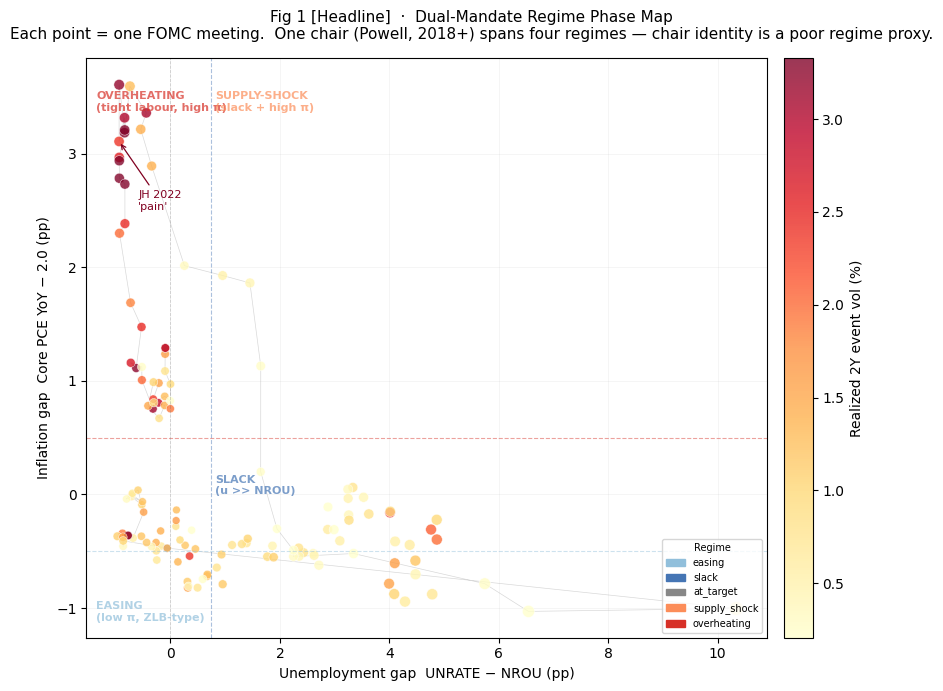

In [9]:
_regime_handles = [
    mpatches.Patch(color=REGIME_PALETTE[lab], label=lab)
    for lab in REGIME_ORDER if lab in REGIME_PALETTE
]


def _save(fig, name: str) -> None:
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved → {path}")
    _display(fig)
    plt.close(fig)


def fig1_phase_map() -> None:
    df = regime_df.merge(model_panel[["meeting_date","rv_gk_2Y"]].dropna(),
                         on="meeting_date", how="left")
    df = df.dropna(subset=["u_gap","inflation_gap"])

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.suptitle(
        "Fig 1 [Headline]  ·  Dual-Mandate Regime Phase Map\n"
        "Each point = one FOMC meeting.  One chair (Powell, 2018+) "
        "spans four regimes — chair identity is a poor regime proxy.",
        fontsize=11)

    # Trajectory arrow chain for Powell
    pw = df[df["meeting_date"] >= POWELL_START].sort_values("meeting_date")
    if len(pw) >= 2:
        ax.plot(pw["u_gap"], pw["inflation_gap"],
                color="grey", lw=0.5, alpha=0.3, zorder=1)

    vol  = df["rv_gk_2Y"].fillna(df["rv_gk_2Y"].median())
    norm = mcolors.Normalize(vmin=vol.quantile(0.05), vmax=vol.quantile(0.95))
    dist = (np.abs(df["u_gap"]) + np.abs(df["inflation_gap"])).fillna(0)
    size = 30 + 70 * (dist / max(dist.max(), 1e-6))

    sc = ax.scatter(df["u_gap"], df["inflation_gap"],
                    c=vol, cmap="YlOrRd", norm=norm,
                    s=size, alpha=0.78, zorder=2,
                    edgecolors="white", linewidth=0.4)
    plt.colorbar(sc, ax=ax, label="Realized 2Y event vol (%)", pad=0.02)

    # Quadrant lines at thresholds
    ax.axhline(+0.5, color="#d73027", lw=0.8, ls="--", alpha=0.45)
    ax.axhline(-0.5, color="#91bfdb", lw=0.8, ls="--", alpha=0.45)
    ax.axvline( 0.0, color="grey",    lw=0.6, ls="--", alpha=0.35)
    ax.axvline(+0.75,color="#4575b4", lw=0.8, ls="--", alpha=0.45)

    # Quadrant labels
    xl, xh = ax.get_xlim(); yl, yh = ax.get_ylim()
    for txt, x, y, col in [
        ("OVERHEATING\n(tight labour, high π)", xl*0.88, yh*0.88, "#d73027"),
        ("SUPPLY-SHOCK\n(slack + high π)",       0.82,    yh*0.88, "#fc8d59"),
        ("EASING\n(low π, ZLB-type)",            xl*0.88, yl*0.88, "#91bfdb"),
        ("SLACK\n(u >> NROU)",                   0.82,    0.0,    "#4575b4"),
    ]:
        ax.text(x, y, txt, fontsize=8, color=col, fontweight="bold", alpha=0.7)

    # Jackson Hole 2022 annotation
    jh = df[df["meeting_date"].between(PAIN_SPEECH_DT - pd.Timedelta(45,"D"),
                                       PAIN_SPEECH_DT + pd.Timedelta(45,"D"))]
    if not jh.empty:
        r = jh.iloc[0]
        ax.annotate("JH 2022\n'pain'",
                    xy=(r["u_gap"], r["inflation_gap"]),
                    xytext=(r["u_gap"] + 0.35, r["inflation_gap"] - 0.6),
                    fontsize=8, color="#800020",
                    arrowprops=dict(arrowstyle="->", color="#800020", lw=0.9))

    ax.set_xlabel("Unemployment gap  UNRATE − NROU (pp)", fontsize=10)
    ax.set_ylabel("Inflation gap  Core PCE YoY − 2.0 (pp)", fontsize=10)
    ax.legend(handles=_regime_handles, fontsize=7, loc="lower right",
              title="Regime", title_fontsize=7)
    ax.grid(True, alpha=0.18, lw=0.5)
    fig.tight_layout()
    _save(fig, "fig1_phase_map")


fig1_phase_map()

---
## Cell 10 — Fig 2: Regime Timeline Strip (Powell Tenure)

Horizontal timeline.  Bottom band = dual-mandate regime colour.
Top line = realized 2Y event vol with regime-coloured scatter points.
Vertical ticks mark FOMC meetings with press conferences (grey)
and Jackson Hole speeches (purple).

  Saved → figures/fig2_regime_timeline.png


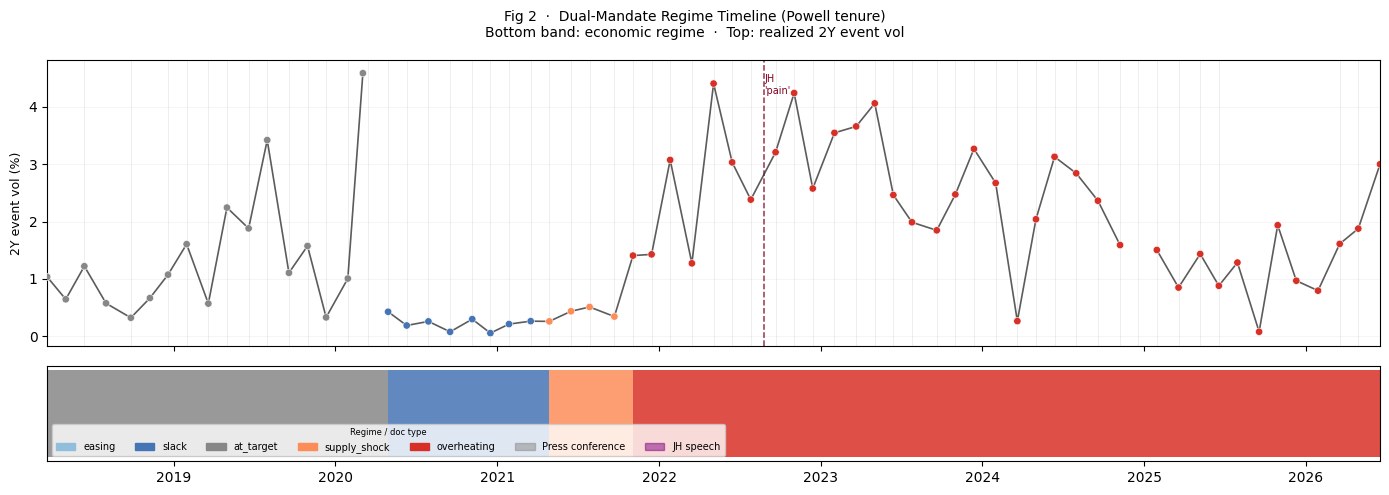

In [10]:
def fig2_timeline() -> None:
    df = regime_df.merge(model_panel[["meeting_date","rv_gk_2Y"]].dropna(),
                         on="meeting_date", how="left")
    df = df[df["meeting_date"] >= POWELL_START].sort_values("meeting_date")
    if df.empty:
        print("  No Powell data — skipping Fig 2."); return

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(14, 5), height_ratios=[3, 1], sharex=True)
    fig.suptitle(
        "Fig 2  ·  Dual-Mandate Regime Timeline (Powell tenure)\n"
        "Bottom band: economic regime  ·  Top: realized 2Y event vol",
        fontsize=10)

    cols = [REGIME_PALETTE.get(l, "#878787") for l in df["regime_label"]]
    ax_top.plot(df["meeting_date"], df["rv_gk_2Y"].fillna(np.nan),
                color="#333333", lw=1.2, zorder=3, alpha=0.8)
    ax_top.scatter(df["meeting_date"], df["rv_gk_2Y"],
                   c=cols, s=28, zorder=4, edgecolors="white", lw=0.4)
    ax_top.set_ylabel("2Y event vol (%)", fontsize=9)
    ax_top.grid(True, axis="y", alpha=0.18, lw=0.5)

    # Pain speech annotation
    ylim = ax_top.get_ylim()
    ax_top.axvline(PAIN_SPEECH_DT, color="#800020", lw=1.1, ls="--", alpha=0.8)
    ax_top.text(PAIN_SPEECH_DT, ylim[1] * 0.95, "JH\n'pain'",
                fontsize=7, color="#800020", ha="left", va="top")

    # Regime colour strip
    dates = df["meeting_date"].values
    for i in range(len(dates) - 1):
        col = REGIME_PALETTE.get(df["regime_label"].iloc[i], "#878787")
        ax_bot.barh(0, (dates[i+1] - dates[i]) / np.timedelta64(1, "D"),
                    left=dates[i], height=0.8, color=col, alpha=0.85, align="edge")
    ax_bot.set_yticks([])
    ax_bot.set_xlim(df["meeting_date"].min(), df["meeting_date"].max())

    # Presser / speech ticks
    for _, row in corpus_df[corpus_df["doc_type"].isin(["presser","speech"]) &
                             (corpus_df["meeting_date"] >= POWELL_START)].iterrows():
        dt  = pd.Timestamp(row["meeting_date"])
        col = "purple" if row["doc_type"] == "speech" else "#888888"
        ax_top.axvline(dt, color=col, lw=0.4, alpha=0.25, zorder=2)

    ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_top.xaxis.set_major_locator(mdates.YearLocator(1))

    presser_h = mpatches.Patch(color="#888888", alpha=0.5, label="Press conference")
    speech_h  = mpatches.Patch(color="purple",  alpha=0.5, label="JH speech")
    ax_bot.legend(handles=_regime_handles + [presser_h, speech_h],
                  fontsize=7, loc="lower left", ncol=7, title="Regime / doc type",
                  title_fontsize=6)
    fig.tight_layout()
    _save(fig, "fig2_regime_timeline")


fig2_timeline()

---
## Cell 11 — Fig 3: Text-Feature × Regime Loading Heatmap

OLS coefficient of each text feature on 2Y realized vol, **estimated
within each regime separately**.  The cell colour shows whether the
feature is positively or negatively loaded for that regime.

**Reading the chart:** the same language loads differently by regime.
If uncertainty language loads positively in overheating but negatively
in easing, that IS the mechanism the interaction terms capture.

  Saved → figures/fig3_loading_heatmap.png


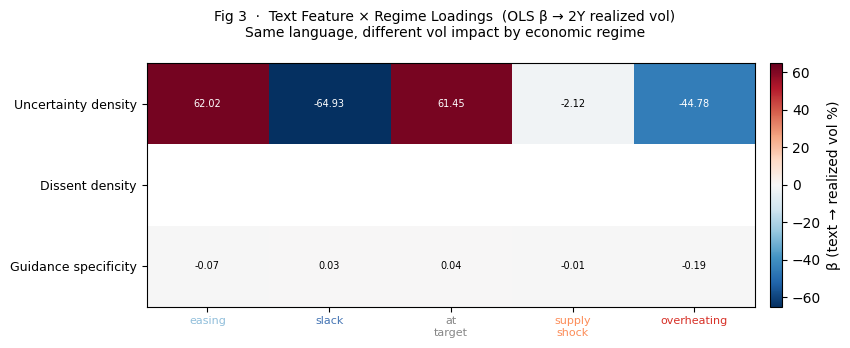


Loading matrix (β):
                      easing   slack  at_target  supply_shock  overheating
Uncertainty density   62.020 -64.930     61.454        -2.122      -44.777
Dissent density          NaN     NaN        NaN           NaN          NaN
Guidance specificity  -0.074   0.027      0.044        -0.014       -0.185


In [11]:
def fig3_heatmap() -> pd.DataFrame:
    target = "rv_gk_2Y"
    feat_labels = {
        "uncertainty_density":  "Uncertainty density",
        "disagree_density":     "Dissent density",
        "guidance_specificity": "Guidance specificity",
    }
    loadings = {}
    for lab in REGIME_ORDER:
        sub = model_panel[model_panel["regime_label"] == lab].dropna(subset=[target])
        betas = {}
        for feat in feat_labels:
            if feat not in sub.columns or sub[feat].std() < 1e-8 or len(sub) < 4:
                betas[feat] = np.nan
                continue
            x    = sub[feat].fillna(0).values.reshape(-1, 1)
            y    = sub[target].values
            betas[feat] = float(LinearRegression().fit(x, y).coef_[0])
        loadings[lab] = betas

    load_df = pd.DataFrame(loadings).reindex(
        index=list(feat_labels.keys()), columns=REGIME_ORDER)
    load_df.index = list(feat_labels.values())
    load_df.to_csv(FIG_DIR / "fig3_loading_matrix.csv")

    fig, ax = plt.subplots(figsize=(9, 3.5))
    fig.suptitle(
        "Fig 3  ·  Text Feature × Regime Loadings  (OLS β → 2Y realized vol)\n"
        "Same language, different vol impact by economic regime",
        fontsize=10)

    mat  = load_df.values.astype(float)
    vmax = max(np.nanmax(np.abs(mat)), 0.01)
    im   = ax.imshow(mat, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label="β (text → realized vol %)", pad=0.02)

    ax.set_xticks(range(len(REGIME_ORDER)))
    ax.set_xticklabels([l.replace("_","\n") for l in REGIME_ORDER], fontsize=8)
    ax.set_yticks(range(len(load_df)))
    ax.set_yticklabels(load_df.index, fontsize=9)
    for tick, lab in zip(ax.get_xticklabels(), REGIME_ORDER):
        tick.set_color(REGIME_PALETTE.get(lab, "black"))

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color=("white" if abs(v) > vmax*0.6 else "black"))
    fig.tight_layout()
    _save(fig, "fig3_loading_heatmap")
    print("\nLoading matrix (β):")
    print(load_df.round(3).to_string())
    return load_df


load_matrix = fig3_heatmap()

---
## Cell 12 — Fig 4 [Headline]: OOS Acceptance Test

**Left/centre:** Predicted vs realised scatter for NLP-only and NLP×regime
(walk-forward OOS only — no in-sample fit shown).
**Right:** Per-regime sign-hit rate bar chart (does the model call direction
correctly within each regime?).

Interpretation: if the right-hand bars are consistently taller for
NLP×regime (orange/regime-coloured) than NLP-only (steel-blue),
regime conditioning is adding directional signal.

  Saved → figures/fig4_oos_scatter.png


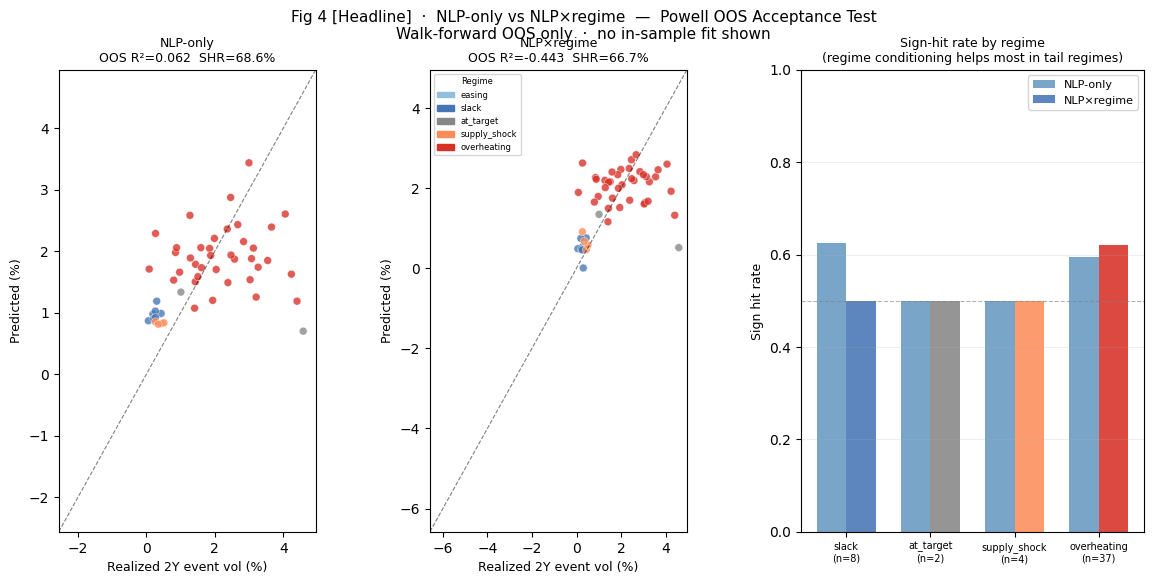

In [12]:
def fig4_oos_scatter() -> None:
    if len(oos) < 5:
        print("  Insufficient OOS observations — skipping Fig 4."); return

    act = oos["actual"].values
    p1  = oos["pred_nlp_only"].values
    p2  = oos["pred_nlp_regime"].values
    cols = [REGIME_PALETTE.get(l, "#878787") for l in oos["regime_label"]]

    def r2(p, a): return float(r2_score(a, p)) if len(a) > 2 else np.nan
    def shr(p, a):
        m = a.mean()
        return float(np.mean(np.sign(p - m) == np.sign(a - m)))

    fig = plt.figure(figsize=(14, 6))
    fig.suptitle(
        "Fig 4 [Headline]  ·  NLP-only vs NLP×regime  —  Powell OOS Acceptance Test\n"
        "Walk-forward OOS only  ·  no in-sample fit shown",
        fontsize=11)

    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4, width_ratios=[3, 3, 4])

    def _scatter(ax, pred, title):
        lim = [min(act.min(), pred.min())*0.88, max(act.max(), pred.max())*1.08]
        ax.scatter(act, pred, c=cols, s=32, alpha=0.78, edgecolors="white", lw=0.35)
        ax.plot(lim, lim, "k--", lw=0.8, alpha=0.5)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel("Realized 2Y event vol (%)", fontsize=9)
        ax.set_ylabel("Predicted (%)", fontsize=9)
        ax.set_title(title, fontsize=9)

    _scatter(fig.add_subplot(gs[0]), p1,
             f"NLP-only\nOOS R²={r2(p1,act):.3f}  SHR={shr(p1,act):.1%}")
    ax1 = fig.add_subplot(gs[1])
    _scatter(ax1, p2,
             f"NLP×regime\nOOS R²={r2(p2,act):.3f}  SHR={shr(p2,act):.1%}")
    ax1.legend(handles=_regime_handles, fontsize=6, loc="upper left",
               title="Regime", title_fontsize=6)

    # Per-regime sign-hit bars
    ax2   = fig.add_subplot(gs[2])
    labs  = [l for l in REGIME_ORDER if l in oos["regime_label"].unique()]
    x     = np.arange(len(labs))
    w     = 0.35
    sh1   = [shr(oos[oos.regime_label==l]["pred_nlp_only"],
                 oos[oos.regime_label==l]["actual"]) for l in labs]
    sh2   = [shr(oos[oos.regime_label==l]["pred_nlp_regime"],
                 oos[oos.regime_label==l]["actual"]) for l in labs]
    ns    = [len(oos[oos.regime_label==l]) for l in labs]

    ax2.bar(x - w/2, sh1, w, color="steelblue",  alpha=0.72, label="NLP-only")
    ax2.bar(x + w/2, sh2, w,
            color=[REGIME_PALETTE.get(l, "#878787") for l in labs],
            alpha=0.88, label="NLP×regime")
    ax2.axhline(0.5, color="grey", lw=0.8, ls="--", alpha=0.6)
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{l}\n(n={n})" for l,n in zip(labs, ns)], fontsize=7)
    ax2.set_ylabel("Sign hit rate", fontsize=9)
    ax2.set_title("Sign-hit rate by regime\n(regime conditioning helps most "
                  "in tail regimes)", fontsize=9)
    ax2.legend(fontsize=8); ax2.set_ylim(0, 1)
    ax2.grid(True, axis="y", alpha=0.2)
    fig.tight_layout()
    _save(fig, "fig4_oos_scatter")


fig4_oos_scatter()

---
## Cell 13 — Fig 5: High-Vol Event Study  (JH 2022 'pain' + peers)

Small-multiples around three known high-vol episodes.
Red bar = the event meeting.  Star (★) = speech or presser in corpus.
Text score (per 1k tokens) annotated above bars.

**JH 2022 'pain' speech** (Powell, Aug 26 2022):
> *"Restoring price stability will take some time and requires using our tools
> forcefully.  We will keep at it until the job is done."*
> — 8-min speech; most concise JH address on record; markets fell sharply.

  Saved → figures/fig5_event_study.png


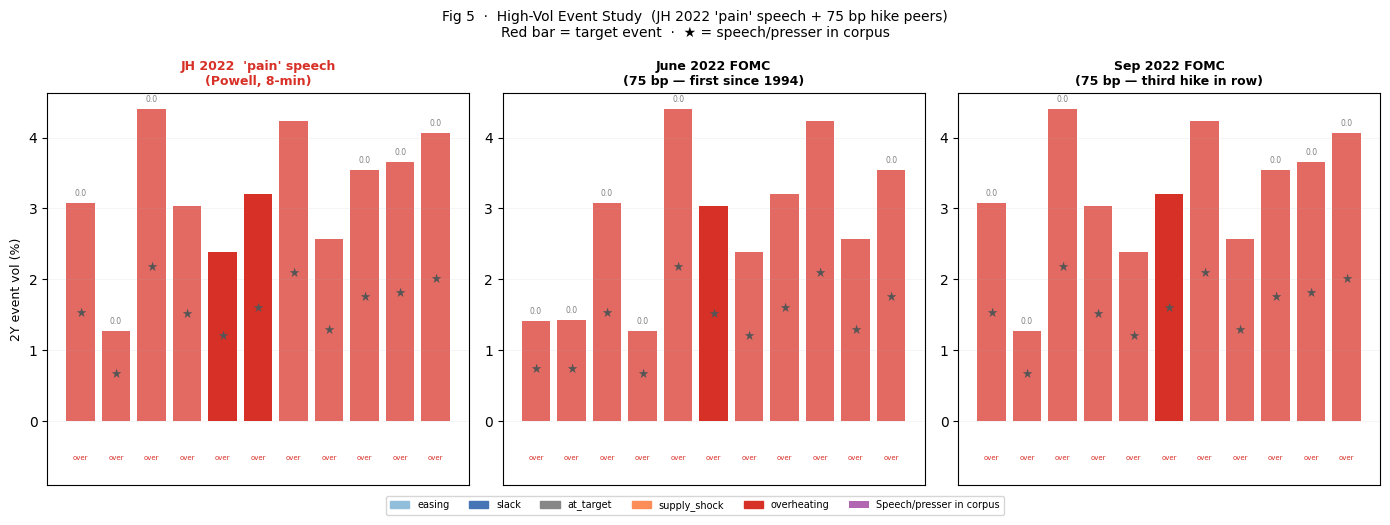

In [13]:
def fig5_event_study() -> None:
    df_p = model_panel.dropna(subset=["rv_gk_2Y"]).sort_values("meeting_date")
    df_p["meeting_date"] = pd.to_datetime(df_p["meeting_date"])

    events = [
        ("2022-08-26", "JH 2022  'pain' speech\n(Powell, 8-min)",   True),
        ("2022-06-15", "June 2022 FOMC\n(75 bp — first since 1994)", False),
        ("2022-09-21", "Sep 2022 FOMC\n(75 bp — third hike in row)", False),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
    fig.suptitle(
        "Fig 5  ·  High-Vol Event Study  (JH 2022 'pain' speech + 75 bp hike peers)\n"
        "Red bar = target event  ·  ★ = speech/presser in corpus",
        fontsize=10)

    for ax, (ev_dt_str, ev_label, is_pain) in zip(axes, events):
        ev_dt = pd.Timestamp(ev_dt_str)
        idx   = df_p["meeting_date"].searchsorted(ev_dt)
        lo, hi = max(0, idx-5), min(len(df_p), idx+6)
        sub   = df_p.iloc[lo:hi]

        bar_cols = [REGIME_PALETTE.get(l, "#878787") for l in sub["regime_label"]]
        ax.bar(range(len(sub)), sub["rv_gk_2Y"], color=bar_cols, alpha=0.72)

        # Highlight target event
        for i, (_, row) in enumerate(sub.iterrows()):
            if abs((row["meeting_date"] - ev_dt).days) < 35:
                ax.bar(i, row["rv_gk_2Y"], color="#d73027", alpha=1.0, zorder=3)

        # Text score above bar
        for i, (_, row) in enumerate(sub.iterrows()):
            uc = float(row.get("uncertainty_density", 0) or 0)
            if uc > 0:
                ax.text(i, row["rv_gk_2Y"] + 0.1, f"{uc:.1f}",
                        fontsize=5.5, ha="center", color="grey")

        # Star for presser/speech
        for i, (_, row) in enumerate(sub.iterrows()):
            match = corpus_df[(corpus_df["meeting_date"] == row["meeting_date"]) &
                              (corpus_df["doc_type"].isin(["speech","presser"]))]
            if not match.empty:
                mc = "purple" if (match["doc_type"] == "speech").any() else "#555555"
                ax.text(i, row["rv_gk_2Y"] * 0.48, "★",
                        fontsize=9, ha="center", color=mc)

        # Regime stripe at bottom
        for i, (_, row) in enumerate(sub.iterrows()):
            ax.text(i, -0.55, str(row["regime_label"])[:4], fontsize=5,
                    ha="center", color=REGIME_PALETTE.get(row["regime_label"], "grey"))

        ax.set_title(ev_label, fontsize=9,
                     color="#d73027" if is_pain else "black", fontweight="bold")
        ax.set_xticks([])
        ax.set_ylabel("2Y event vol (%)" if ax is axes[0] else "", fontsize=9)
        ax.set_ylim(bottom=-0.9)
        ax.grid(True, axis="y", alpha=0.18, lw=0.5)

    star_h = mpatches.Patch(facecolor="purple", alpha=0.6, label="Speech/presser in corpus")
    fig.legend(handles=_regime_handles + [star_h], fontsize=7,
               loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout()
    _save(fig, "fig5_event_study")


fig5_event_study()

---
## Cell 14 — Fig 6: Doc-Type Ablation

Walk-forward OOS sign-hit rate as the corpus expands from
statements only → + press conferences → + Jackson Hole speeches.

**Honest reporting:** if bars do **not** rise, we report that.
Adding text is only valuable if it adds OOS signal — not just if it
feels richer.

  Statements only                SHR=45.1%  n=51
  + Press conferences            SHR=45.1%  n=51
  + Jackson Hole speeches        SHR=45.1%  n=51


  Saved → figures/fig6_ablation.png


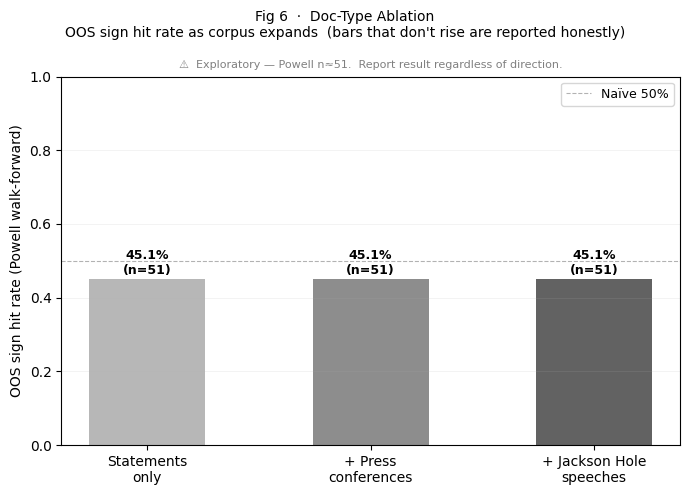

In [14]:
def fig6_ablation() -> None:
    target  = "rv_gk_2Y"
    subs_pw = model_panel[model_panel["meeting_date"] >= POWELL_START].dropna(
        subset=[target]).sort_values("meeting_date").reset_index(drop=True)
    meetings = sorted(subs_pw["meeting_date"].unique())

    def _oos_shr(zero_out_feats: set[str]) -> tuple[float, int]:
        hits = []
        sub  = subs_pw.copy()
        for f in zero_out_feats:
            if f in sub.columns:
                sub[f] = 0.0
        for i, dt in enumerate(meetings):
            if i < MIN_TRAIN: continue
            tr = sub[sub["meeting_date"] < dt].dropna(subset=TEXT_FEATURES[:2] + [target])
            te = sub[sub["meeting_date"] == dt]
            if len(tr) < 8 or te.empty: continue
            cols = [c for c in TEXT_FEATURES if c in tr.columns]
            scaler = StandardScaler()
            X_tr   = scaler.fit_transform(tr[cols].fillna(0).values)
            X_te   = scaler.transform(te[cols].fillna(0).values)
            try:
                pred = RidgeCV(alphas=ALPHA_RANGE).fit(X_tr, tr[target].values).predict(X_te)[0]
                hits.append(int(np.sign(pred - tr[target].mean()) ==
                                np.sign(te[target].iloc[0] - tr[target].mean())))
            except Exception:
                continue
        return (float(np.mean(hits)) if hits else np.nan, len(hits))

    configs = [
        ("Statements\nonly",          {"uncertainty_density_presser","disagree_density_presser",
                                       "guidance_specificity_presser"}),
        ("+ Press\nconferences",      {"guidance_specificity_speech","uncertainty_density_speech"}),
        ("+ Jackson Hole\nspeeches",  set()),
    ]

    rates, ns = [], []
    for lbl, zeroed in configs:
        r, n = _oos_shr(zeroed)
        rates.append(r); ns.append(n)
        print(f"  {lbl.replace(chr(10),' '):<30} SHR={r:.1%}  n={n}")

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(
        "Fig 6  ·  Doc-Type Ablation\n"
        "OOS sign hit rate as corpus expands  "
        "(bars that don't rise are reported honestly)",
        fontsize=10)

    labels = [l for l, _ in configs]
    bars   = ax.bar(labels, rates, color=["#aaaaaa","#777777","#444444"],
                    alpha=0.84, width=0.52)
    ax.axhline(0.5, color="grey", lw=0.8, ls="--", alpha=0.6, label="Naïve 50%")
    for b, r, n in zip(bars, rates, ns):
        if not np.isnan(r):
            ax.text(b.get_x() + b.get_width()/2, r + 0.012, f"{r:.1%}\n(n={n})",
                    ha="center", fontsize=9, fontweight="bold")

    ax.set_ylim(0, 1)
    ax.set_ylabel("OOS sign hit rate (Powell walk-forward)", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", alpha=0.2, lw=0.5)
    ax.set_title(
        f"⚠  Exploratory — Powell n≈{ns[-1]}.  Report result regardless of direction.",
        fontsize=8, color="grey")
    fig.tight_layout()
    _save(fig, "fig6_ablation")


fig6_ablation()

---
## Cell 15 — Caveats & Output Summary

**Five caveats to carry into any presentation:**

1. **Regime conditioning can overfit.** Validated OOS on Powell (Fig 4).
   If the acceptance test returns `FLAG`, do **not** claim the mechanism.

2. **Press-conference / speech normalisation.** Scores are densities per 1k tokens —
   not raw counts.  Do not compare raw scores across `doc_type`.

3. **Dual-mandate regime is economically primitive.** UNRATE / PCEPILFE / NROU
   are defined by BLS/BEA/FOMC — never from vol outcomes.  Thresholds
   are Taylor-rule intuition, not vol-calibrated.

4. **Powell is the backtest; Warsh is the forward test.**  Warsh CI is very wide (n=1+).

5. **Small sample.** Powell ≈ 55 meetings; OOS ≈ 40.  Bootstrap CIs are wide.
   Per-regime cells may have n < 10.

In [15]:
print("═" * 62)
print("  OUTPUT SUMMARY")
print("═" * 62)
print(f"  Corpus   : {CORPUS_OUT}")
print(f"  Regime   : {REGIME_OUT}")
print(f"  Forecasts: {MODEL_OUT}")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  Figure   : {f}")
print(f"  Loading matrix: {FIG_DIR/'fig3_loading_matrix.csv'}")
print("═" * 62)
print()
print(f"  Acceptance-test verdict : {verdict}")
print()
print("  CAVEATS")
print("  1. If acceptance test = FLAG, do not claim the mechanism.")
print("  2. Score densities per 1k tokens — not raw counts.")
print("  3. Dual-mandate regime never derived from vol outcomes.")
print("  4. Warsh is forward test (n=1+), NOT validation.")
print("  5. Small sample — all results are exploratory.")

══════════════════════════════════════════════════════════════
  OUTPUT SUMMARY
══════════════════════════════════════════════════════════════
  Corpus   : fomc_corpus_expanded.parquet
  Regime   : fomc_dual_mandate_regime.parquet
  Forecasts: fomc_nlp_regime_forecasts.parquet
  Figure   : figures/diag_d1_stage1.png
  Figure   : figures/diag_d2_spec_comparison.png
  Figure   : figures/diag_d4_full_history.png
  Figure   : figures/diag_d5_warsh.png
  Figure   : figures/fig1_phase_map.png
  Figure   : figures/fig2_regime_timeline.png
  Figure   : figures/fig3_loading_heatmap.png
  Figure   : figures/fig4_oos_scatter.png
  Figure   : figures/fig5_event_study.png
  Figure   : figures/fig6_ablation.png
  Figure   : figures/vrp_v1_regime_distribution.png
  Figure   : figures/vrp_v2_timeseries.png
  Figure   : figures/vrp_v3_calibration.png
  Figure   : figures/vrp_v4_nlp_iv_alignment.png
  Figure   : figures/vrp_v5_warsh.png
  Figure   : figures/vrp_v6_four_series.png
  Figure   : figures/vr